In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from faker import Faker
import random

print("Ready to build!")

Ready to build!


In [2]:
fake = Faker('de_DE')
random.seed(42)

cities = ['Berlin', 'Munich', 'Frankfurt', 'Hamburg', 'Darmstadt']
services = ['Private Spa', 'Birthday Party', 'Couples Session', 'Group Session']
fnb_items = ['Pizza', 'Coffee', 'Coca Cola', 'Champagne', 'None']
months = list(range(1, 13))

num_bookings = 500

data = {
    'booking_id': range(1, num_bookings + 1),
    'client_name': [fake.name() for _ in range(num_bookings)],
    'city': [random.choice(cities) for _ in range(num_bookings)],
    'month': [random.choice(months) for _ in range(num_bookings)],
    'service_type': [random.choice(services) for _ in range(num_bookings)],
    'fnb_order': [random.choice(fnb_items) for _ in range(num_bookings)],
    'group_size': [random.randint(1, 10) for _ in range(num_bookings)],
    'duration_hours': [random.choice([1, 2, 3, 4]) for _ in range(num_bookings)],
    'revenue_eur': [random.randint(80, 800) for _ in range(num_bookings)],
    'supply_cost_eur': [random.randint(20, 150) for _ in range(num_bookings)],
    'satisfaction_score': [random.randint(1, 10) for _ in range(num_bookings)],
}

df = pd.DataFrame(data)
print(df.head())

   booking_id                  client_name       city  month     service_type  \
0           1             Irmingard Aumann     Berlin     12    Group Session   
1           2         Gertraud Scheuermann     Berlin      3    Group Session   
2           3  Eckhart Tschentscher B.Eng.  Frankfurt     11      Private Spa   
3           4                   Gereon Heß     Munich      2    Group Session   
4           5            Sieghard Hendriks     Munich      5  Couples Session   

   fnb_order  group_size  duration_hours  revenue_eur  supply_cost_eur  \
0  Champagne           9               2          207               88   
1      Pizza           2               1          241               34   
2  Champagne           6               3          531               76   
3  Champagne           4               4          547              119   
4  Coca Cola           8               1           80              110   

   satisfaction_score  
0                   5  
1                   

In [7]:
df.groupby('city')['satisfaction_score'].mean().sort_values(ascending=False)


city
Hamburg      5.818182
Munich       5.660377
Frankfurt    5.489796
Darmstadt    5.415842
Berlin       5.327103
Name: satisfaction_score, dtype: float64

In [3]:
df['profit_eur'] = df['revenue_eur'] - df['supply_cost_eur']
print(df[['booking_id', 'city', 'revenue_eur', 'supply_cost_eur', 'profit_eur']].head(10))

   booking_id       city  revenue_eur  supply_cost_eur  profit_eur
0           1     Berlin          207               88         119
1           2     Berlin          241               34         207
2           3  Frankfurt          531               76         455
3           4     Munich          547              119         428
4           5     Munich           80              110         -30
5           6     Munich          518               64         454
6           7     Berlin          287               65         222
7           8  Darmstadt          785               80         705
8           9     Berlin          215              101         114
9          10  Darmstadt          745              111         634


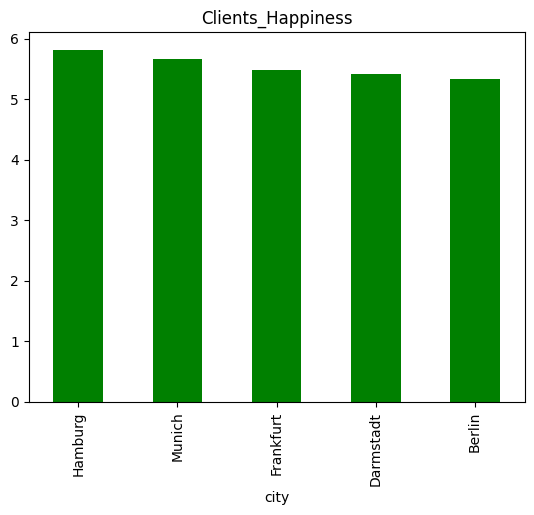

In [9]:
df.groupby('city')['satisfaction_score'].mean().sort_values(ascending=False).plot(kind='bar', color='green')
plt.title('Clients_Happiness')
plt.show()

In [10]:
df.groupby(['city' , 'service_type']).size() .sort_values(ascending = False)

city       service_type   
Frankfurt  Private Spa        35
Hamburg    Group Session      33
Berlin     Group Session      31
           Couples Session    28
Munich     Couples Session    28
Darmstadt  Couples Session    28
Munich     Birthday Party     28
Berlin     Private Spa        27
Darmstadt  Birthday Party     26
Munich     Group Session      26
Hamburg    Couples Session    24
Darmstadt  Group Session      24
Munich     Private Spa        24
Frankfurt  Group Session      23
Darmstadt  Private Spa        23
Frankfurt  Couples Session    22
Berlin     Birthday Party     21
Frankfurt  Birthday Party     18
Hamburg    Birthday Party     16
           Private Spa        15
dtype: int64

In [4]:
city_profit = df.groupby('city')['profit_eur'].sum().sort_values(ascending=False)
print(city_profit)

city
Darmstadt    39638
Berlin       35083
Munich       33512
Frankfurt    31990
Hamburg      28221
Name: profit_eur, dtype: int64


In [5]:
df.groupby('month')['revenue_eur'].sum().sort_values(ascending=False)

month
5     24022
4     23407
8     22425
10    18497
12    18173
7     17465
2     16081
3     15594
11    14322
1     14292
9     13583
6     12614
Name: revenue_eur, dtype: int64

Key Business Insights

- Most Profitable City: Darmstadt
- Happiest Customers: Hamburg
- Most Popular Service: Frankfurt - Private Spa
- Peak Revenue Month: May

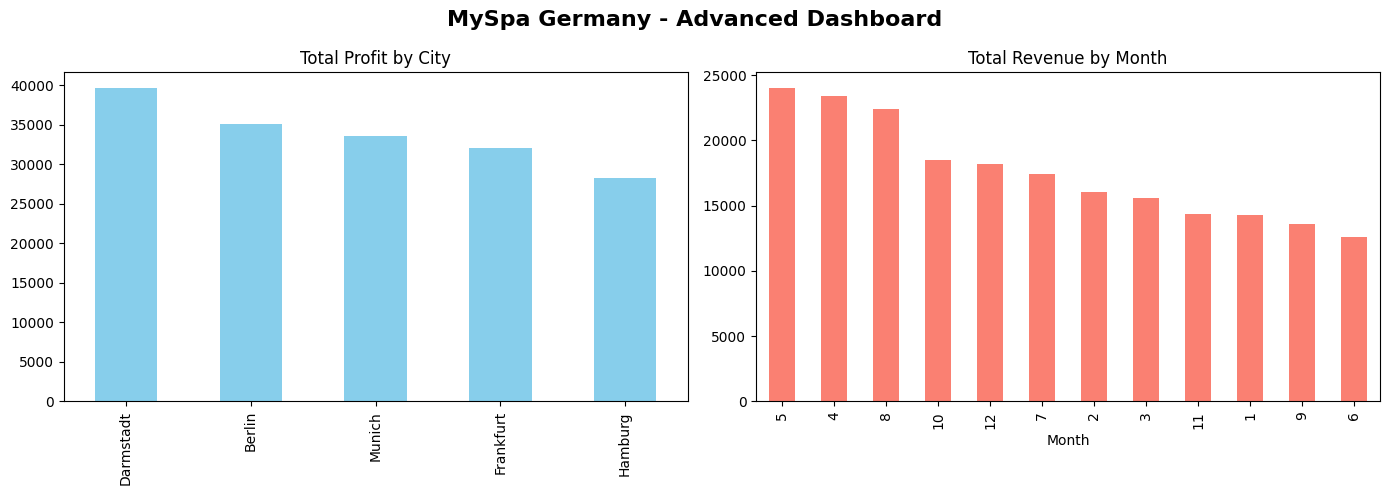

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MySpa Germany - Advanced Dashboard', fontsize=16, fontweight='bold')

# Chart 1 - Profit by City
df.groupby('city')['profit_eur'].sum().sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Total Profit by City')
axes[0].set_xlabel('')

# Chart 2 - Revenue by Month
df.groupby('month')['revenue_eur'].sum().sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Total Revenue by Month')
axes[1].set_xlabel('Month')

plt.tight_layout()
plt.show()